# Exploratory Data Analysis

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# Configure display options
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')

df = pd.read_csv('clean_task_data.csv')
df.info()

df.columns = df.columns.str.lower().str.replace(' ', '_').str.replace('__', '_')
# Standardize all column names to lowercase with underscores (snake_case)

In [ ]:
# 1) Datetime columns
datetime_cols = ["timestamp", "converted_at", "trial_start", "trial_end"]
for col in datetime_cols:
    df[col] = pd.to_datetime(df[col], errors="coerce")

# 2) Boolean columns (nullable boolean dtype)
for col in ["converted", "late_conversion"]:
    df[col] = df[col].astype("boolean")

# 3) Numeric columns
int_cols = ["days_into_trial", "trial_week", "days_to_convert"]
for col in int_cols:
    df[col] = pd.to_numeric(df[col], errors="coerce").astype("Int64")

# 4) String / categorical columns
df["organization_id"] = df["organization_id"].astype("string")
df["activity_name"] = df["activity_name"].astype("string")

# Trial month name as ordered category
month_order = [
    "January", "February", "March", "April", "May", "June",
    "July", "August", "September", "October", "November", "December"
]
df["trial_start_month"] = pd.Categorical(df["trial_start_month"], categories=month_order, ordered=True)

# Optional: quick check
df.dtypes

In [ ]:
df

### Distribution of Organization

In [ ]:
# Count distinct organizations
total_orgs = df['organization_id'].nunique()

# organizations that converted
converted_orgs = df[df['converted'] == True]['organization_id'].nunique()
perc_converted_orgs = (converted_orgs / total_orgs) * 100

# organizations that did NOT convert
unconverted_orgs = df[df['converted'] == False]['organization_id'].nunique()
perc_unconverted_orgs = (unconverted_orgs / total_orgs) * 100

print(f"\nSummary:")
print(f"  Total Organisations   : {total_orgs}")
print(f"  Converted             : {converted_orgs} ({perc_converted_orgs:.2f}%)")
print(f"  Not Converted         : {unconverted_orgs} ({perc_unconverted_orgs:.2f}%)")

In [ ]:
# organization conversion distribution
fig, ax = plt.subplots(figsize=(10, 7))
org_distribution = [converted_orgs, unconverted_orgs]
labels = [f'Converted\n({converted_orgs})', f'Not Converted\n({unconverted_orgs})']
colors = ['#2ecc71', '#e74c3c']
explode = (0.05, 0.05)

wedges, texts, autotexts = ax.pie(org_distribution, labels=labels, autopct='%1.1f%%', 
                                    colors=colors, explode=explode, startangle=90,
                                    textprops={'fontsize': 12})

for autotext in autotexts:
    autotext.set_color('white')
    autotext.set_fontweight('bold')
    autotext.set_fontsize(12)

ax.set_title(f'Organization Conversion Distribution\n(Total: {total_orgs} organizations)', 
             fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

### Conversion Timing: Before vs After Trial End Date

In [ ]:
# Identify organizations that converted before vs after trial end date
org_conversion_timing = (
    df[df['converted'] == True]
    .copy()
)

# Create a column to determine if conversion happened before or after trial end
org_conversion_timing['conversion_timing'] = org_conversion_timing.apply(
    lambda row: 'Before Trial End' if row['converted_at'] <= row['trial_end'] else 'After Trial End',
    axis=1
)

# Count organizations by conversion timing
org_timing_summary = org_conversion_timing.groupby('organization_id', as_index=False)['conversion_timing'].first()
timing_distribution = org_timing_summary['conversion_timing'].value_counts()

# print("\nConversion Timing Summary:")
# print(timing_distribution)
print(f"\Converted organisation Distribution:")
for timing_type, count in timing_distribution.items():
    pct = (count / timing_distribution.sum()) * 100
    print(f"  {timing_type}: {count} ({pct:.2f}%)")

# Create bar chart
fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.bar(timing_distribution.index, timing_distribution.values, 
               color=['#3498db', '#e67e22'], edgecolor='black', linewidth=1.5)

# Add value labels on bars
for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{int(height)}',
            ha='center', va='bottom', fontsize=12, fontweight='bold')

ax.set_xlabel('Conversion Timing', fontsize=12, fontweight='bold')
ax.set_ylabel('Number of Organizations', fontsize=12, fontweight='bold')
ax.set_title('Distribution of Organizations: Conversions Before vs After Trial End Date', 
             fontsize=14, fontweight='bold', pad=20)
ax.set_ylim(0, max(timing_distribution.values) * 1.1)
plt.tight_layout()
plt.show()

### Organization Level Summary

In [ ]:
# Rebuild org-level summary from event-level df
org_summary = (
    df.groupby("organization_id", as_index=False)
      .agg(
          total_events=("activity_name", "count"),
          unique_activities=("activity_name", "nunique"),
          trial_days_active=("days_into_trial", "nunique"),
          converted=("converted", "first"),
          late_conversion=("late_conversion", "first"),
          cohort_month=("cohort_month", "first"),
          days_to_convert=("days_to_convert", "first"),
      )
)

total_orgs = len(org_summary)
converted_orgs = int(org_summary["converted"].sum())
unconverted_orgs = int((~org_summary["converted"]).sum())
conversion_rate = org_summary["converted"].mean() * 100
org_summary.sort_values("total_events", ascending=False)


### Low-Activity Organizations (Potential Ghost Signups)

In [ ]:
# Flag low-activity orgs (potential ghost signups)
low_activity_threshold = 3
low_activity_orgs = org_summary[org_summary['total_events'] <= low_activity_threshold]

print(f'Orgs with ≤{low_activity_threshold} events: {len(low_activity_orgs)}')
print()
print('Conversion rate of low-activity orgs:', low_activity_orgs['converted'].mean().round(3))

org_summary['low_activity_flag'] = org_summary['total_events'] <= low_activity_threshold

display(low_activity_orgs[['organization_id','total_events','unique_activities','converted']])

### Activity level Summary

In [ ]:
# Total unique activities
total_activity = df["activity_name"].nunique()
print(f"Total activity count: {total_activity}")

# Activity frequency overview
total_records = df["activity_name"].value_counts(dropna=False).reset_index()
total_records.columns = ["activity_name", "event_count"]
total_records["pct_of_events"] = (total_records["event_count"] / len(df) * 100).round(2)

# % of orgs that ever used each activity
activity_adoption = (
    df.groupby("activity_name", dropna=False)["organization_id"]
      .nunique()
      .reset_index()
)
activity_adoption.columns = ["activity_name", "orgs_using"]
activity_adoption["adoption_pct"] = (activity_adoption["orgs_using"] / org_summary.shape[0] * 100).round(1)

activity_profile = (
    total_records.merge(activity_adoption, on="activity_name", how="left")
                   .sort_values("event_count", ascending=False)
                   .reset_index(drop=True)
)


display(activity_profile)

### Actitivity adoption rate

In [ ]:
fig, ax = plt.subplots(figsize=(10, 9))

colors = ['#4C72B0' if p >= 10 else '#C4C4C4' for p in activity_profile['adoption_pct']]
bars = ax.barh(activity_profile['activity_name'], activity_profile['adoption_pct'], color=colors, edgecolor='white')

ax.set_xlabel('% of Organisations That Used This Activity')
ax.set_title('Activity Adoption Rate Across All Trialists', fontweight='bold', fontsize=13)
ax.axvline(x=10, color='red', linestyle='--', alpha=0.5, label='10% threshold')
ax.legend()
ax.invert_yaxis()

for bar, val in zip(bars, activity_profile['adoption_pct']):
    ax.text(val + 0.5, bar.get_y() + bar.get_height()/2, f'{val}%', va='center', fontsize=8)

plt.tight_layout()
plt.savefig('fig_03_activity_adoption.png', bbox_inches='tight')
plt.show()

### Comparison

In [ ]:
converted = df[df["converted"] == True].copy()
not_converted = df[df["converted"] == False].copy()

# Prepare data for non-converted organizations
non_converted_activity_adoption = (
    not_converted.groupby("activity_name", dropna=False)["organization_id"]
    .nunique()
    .reset_index()
)
non_converted_activity_adoption.columns = ["activity_name", "orgs_using"]
non_converted_activity_adoption["adoption_pct"] = (
    non_converted_activity_adoption["orgs_using"] / unconverted_orgs * 100
).round(1)

# Prepare data for converted organizations
converted_activity_adoption = (
    converted.groupby("activity_name", dropna=False)["organization_id"]
    .nunique()
    .reset_index()
)
converted_activity_adoption.columns = ["activity_name", "orgs_using"]
converted_activity_adoption["adoption_pct_converted"] = (
    converted_activity_adoption["orgs_using"] / converted_orgs * 100
).round(1)

# Merge converted and non-converted data
diverging_data = (
    converted_activity_adoption[["activity_name", "adoption_pct_converted"]]
    .merge(non_converted_activity_adoption[["activity_name", "adoption_pct"]], on="activity_name", how="outer")
    .fillna(0)
    .rename(columns={"adoption_pct_converted": "converted_pct", "adoption_pct": "non_converted_pct"})
    .sort_values("converted_pct", ascending=True)
)

# Create diverging bar chart
fig, ax = plt.subplots(figsize=(12, 10))

y_pos = np.arange(len(diverging_data))
bars1 = ax.barh(y_pos, -diverging_data['non_converted_pct'], 
                color='#e74c3c', edgecolor='black', linewidth=1, alpha=0.85, label='Non-Converted')
bars2 = ax.barh(y_pos, diverging_data['converted_pct'], 
                color='#2ecc71', edgecolor='black', linewidth=1, alpha=0.85, label='Converted')

# Add center line
ax.axvline(x=0, color='black', linewidth=2)

# Customize y-axis
ax.set_yticks(y_pos)
ax.set_yticklabels(diverging_data['activity_name'], fontsize=10)

# Add value labels
for i, (non_conv, conv) in enumerate(zip(diverging_data['non_converted_pct'], diverging_data['converted_pct'])):
    ax.text(-non_conv - 1.5, i, f'{non_conv:.1f}%', va='center', ha='right', fontweight='bold', fontsize=9)
    ax.text(conv + 1.5, i, f'{conv:.1f}%', va='center', ha='left', fontweight='bold', fontsize=9)

ax.set_xlabel('% of Organizations Using Activity', fontsize=12, fontweight='bold')
ax.set_title('Activity Adoption: Diverging Comparison of Converted vs Non-Converted Organizations', 
             fontsize=13, fontweight='bold', pad=20)
ax.legend(loc='lower right', fontsize=11)
ax.invert_yaxis()

plt.tight_layout()
plt.savefig('fig_activity_adoption_diverging.png', bbox_inches='tight', dpi=300)
plt.show()

### Week 1 Activity Adoption Analysis

In [ ]:
# Filter for week 1 activities (first 7 days)
week1 = df[df['days_into_trial'] < 7].copy()

# Create org_conv mapping from org_summary
org_conv = org_summary.set_index('organization_id')['converted']

# Binary: did each org use each activity in week 1?
week1_pivot = week1.groupby(['organization_id','activity_name']).size().unstack(fill_value=0).clip(upper=1)
week1_pivot['converted'] = org_conv.reindex(week1_pivot.index).fillna(False).astype('boolean')

activities = [c for c in week1_pivot.columns if c != 'converted']

rows = []
for act in activities:
    pct_conv    = week1_pivot[week1_pivot['converted']==True][act].mean()  * 100
    pct_notconv = week1_pivot[week1_pivot['converted']==False][act].mean() * 100
    rows.append({
        'activity'           : act,
        'pct_converters'     : round(pct_conv, 1),
        'pct_non_converters' : round(pct_notconv, 1),
        'gap'                : round(pct_conv - pct_notconv, 1)
    })

adoption = pd.DataFrame(rows).sort_values('pct_converters', ascending=False)
adoption['label'] = adoption['activity'].apply(
    lambda x: '.'.join(x.split('.')[-2:]) if x.count('.') >= 2 else x.split('.')[-1]
)

print('Week 1 Adoption Table (sorted by converter adoption):')
display(adoption[['activity','pct_converters','pct_non_converters','gap']])

### Activity × Week Heatmap: Converted vs Non-Converted Organizations

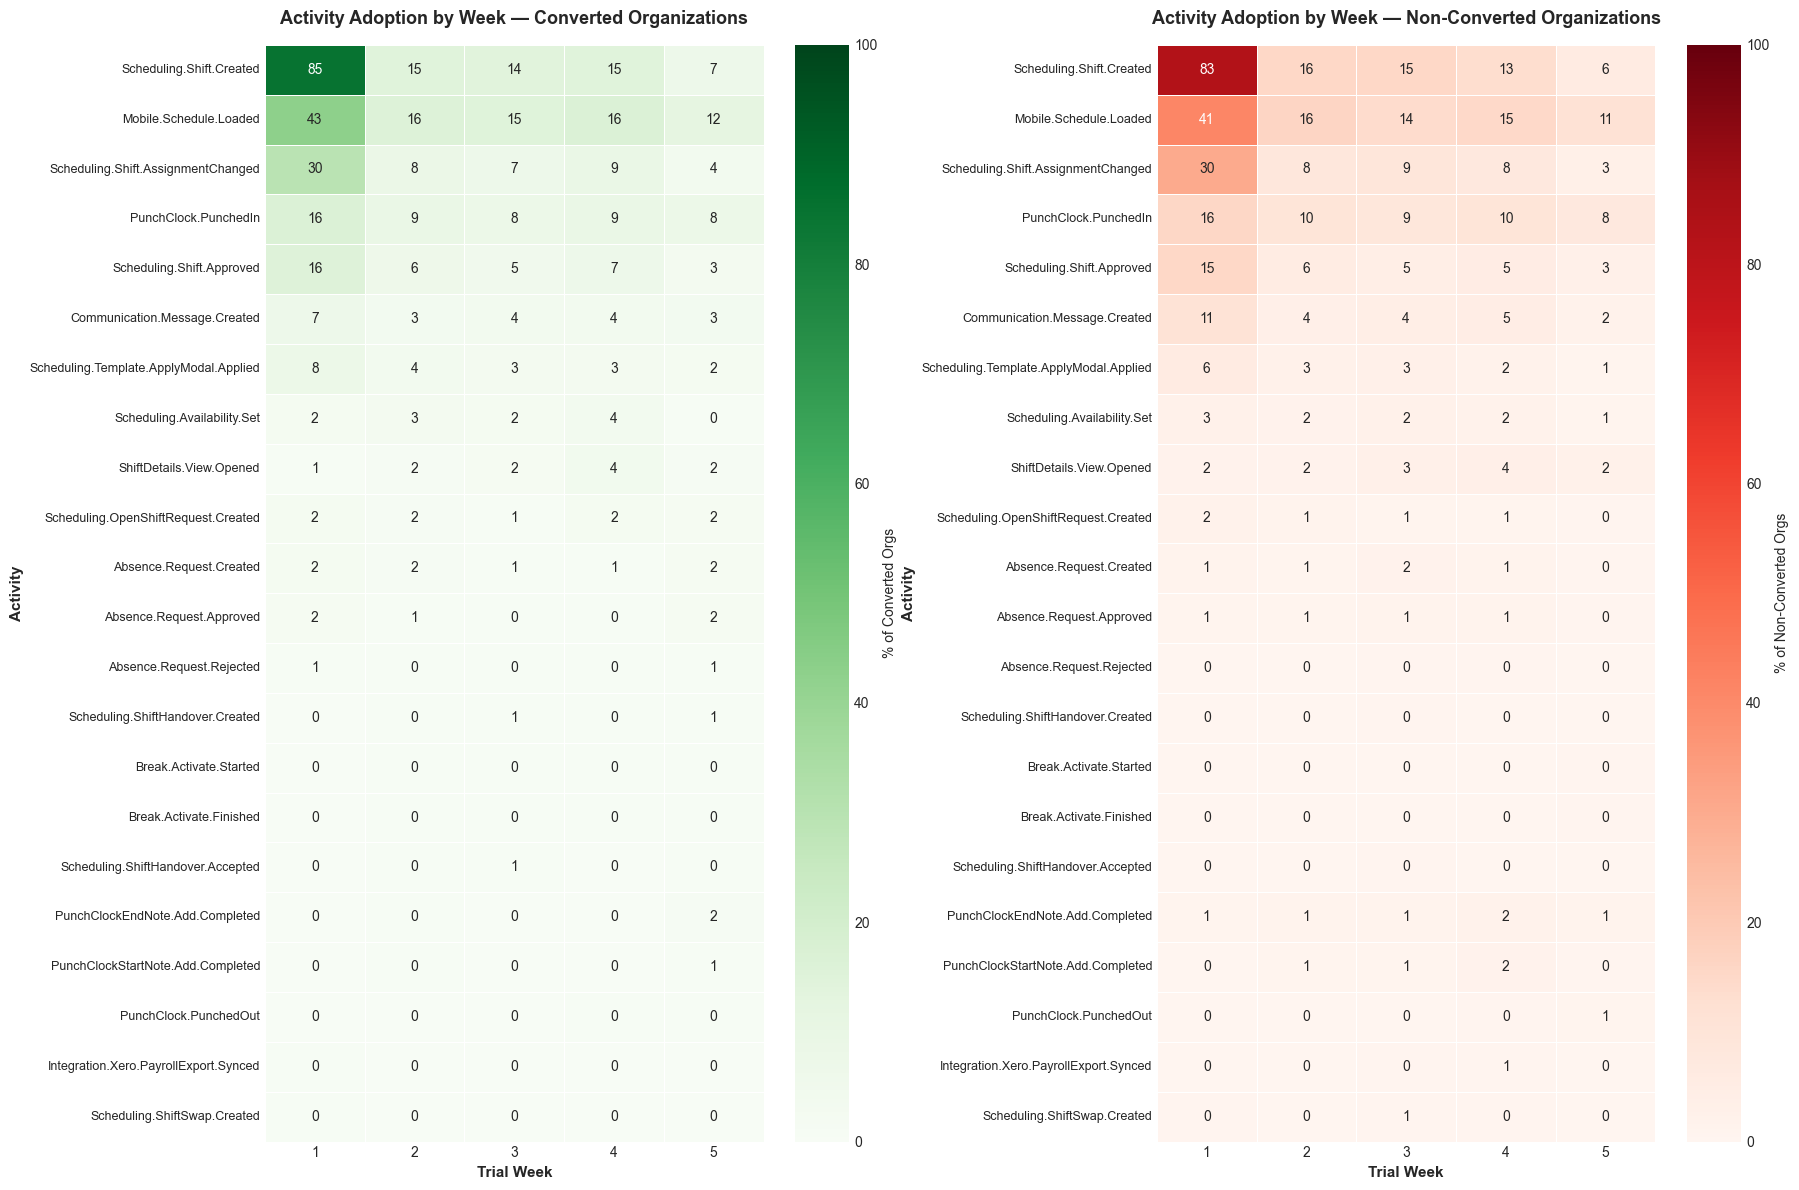

✓ Heatmap: 22 activities × 5 weeks


In [18]:
# Create activity × week heatmaps for both groups
# Create pivot tables: activity × week, counting orgs using that activity in that week
converted_activity_week = (
    converted.groupby(['activity_name', 'trial_week'])['organization_id']
    .nunique()
    .unstack(fill_value=0)
)

not_converted_activity_week = (
    not_converted.groupby(['activity_name', 'trial_week'])['organization_id']
    .nunique()
    .unstack(fill_value=0)
)

# Convert to percentages and sort by mean adoption (converted orgs)
converted_activity_week_pct = (converted_activity_week / converted_orgs * 100).round(1)
not_converted_activity_week_pct = (not_converted_activity_week / unconverted_orgs * 100).round(1)

# Sort by mean % of converted orgs (descending) and apply same order to both
sorted_idx = converted_activity_week_pct.mean(axis=1).sort_values(ascending=False).index
converted_activity_week_pct = converted_activity_week_pct.loc[sorted_idx]
not_converted_activity_week_pct = not_converted_activity_week_pct.reindex(sorted_idx, fill_value=0)

# Create side-by-side heatmaps
fig, axes = plt.subplots(1, 2, figsize=(18, 12))
data_pairs = [
    (converted_activity_week_pct, axes[0], 'Greens', '% of Converted Orgs', 'Converted'),
    (not_converted_activity_week_pct, axes[1], 'Reds', '% of Non-Converted Orgs', 'Non-Converted')
]

for data, ax, cmap, cbar_label, group_name in data_pairs:
    sns.heatmap(data, annot=True, fmt='.0f', cmap=cmap, 
                cbar_kws={'label': cbar_label}, ax=ax, linewidths=0.5, 
                linecolor='white', vmin=0, vmax=100)
    ax.set_title(f'Activity Adoption by Week — {group_name} Organizations', 
                 fontsize=13, fontweight='bold', pad=15)
    ax.set_xlabel('Trial Week', fontsize=11, fontweight='bold')
    ax.set_ylabel('Activity', fontsize=11, fontweight='bold')
    ax.tick_params(axis='y', labelsize=9)

plt.tight_layout()
plt.savefig('fig_activity_week_heatmap_comparison.png', bbox_inches='tight', dpi=300)
plt.show()

print(f"✓ Heatmap: {converted_activity_week_pct.shape[0]} activities × {converted_activity_week_pct.shape[1]} weeks")

In [ ]:
# Event volume over trial days — converters vs non-converters
daily_activity = df.groupby(['days_into_trial', 'converted']).size().reset_index(name='event_count')

fig, ax = plt.subplots(figsize=(12, 4))

for conv, grp in daily_activity.groupby('converted'):
	label = 'Converted' if conv else 'Not Converted'
	color = '#2ecc71' if conv else '#e74c3c'
	ax.plot(grp['days_into_trial'], grp['event_count'], label=label, color=color, linewidth=2)

ax.set_title('Daily Event Volume During Trial — Converters vs Non-Converters', fontweight='bold', fontsize=13)
ax.set_xlabel('Days into Trial')
ax.set_ylabel('Total Events')
ax.legend()
plt.tight_layout()
plt.savefig('fig_04_daily_activity_by_conversion.png', bbox_inches='tight')
plt.show()